# InSARFlow — demo

Denoise real and synthetic InSAR phase with the trained checkpoints in `ckpt/`,
and display **raw → denoised → ground truth**.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import Normalize

from insarflow.data import MexicoDataset, SimulationInSARDataset
from insarflow.model import InSARFlow
from insarflow.utils.logger import show

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").is_file():
    ROOT = ROOT.parent

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
IMG_SIZE, N_SAMPLES, N_STEPS = 256, 3, 5

## Load datasets

In [2]:
mexico = MexicoDataset(split="test", root_dir=str(ROOT / "data" / "mexico"), img_size=IMG_SIZE)
mexico_raw = torch.stack([torch.as_tensor(np.float32(mexico[i]["x0"])) for i in range(N_SAMPLES)])
mexico_clean = torch.stack([torch.as_tensor(np.float32(mexico[i]["x1"])) for i in range(N_SAMPLES)])


simulation = SimulationInSARDataset(split="test", root_dir=str(ROOT / "data" / "simulation"), img_size=IMG_SIZE)
simulation_raw = torch.stack([torch.as_tensor(np.float32(simulation[i]["x0"])) for i in range(N_SAMPLES)])
simulation_clean = torch.stack([torch.as_tensor(np.float32(simulation[i]["x1"])) for i in range(N_SAMPLES)])


## Load Models

`InSARFlow.from_checkpoint` rebuilds the model from the config stored in the `.ckpt`
(backbone, manifold, image size) and loads the weights. `denoise` then solves the flow-matching
ODE on the flat torus, starting from the noisy phase.

In [3]:
mexico_insarflow, _ = InSARFlow.from_checkpoint(str(ROOT / "ckpt" / "mexico.ckpt"), device=DEVICE)
mexico_insarflow.eval()
simulation_insarflow, _ = InSARFlow.from_checkpoint(str(ROOT / "ckpt" / "simulation.ckpt"), device=DEVICE)
simulation_insarflow.eval()

InSARFlow(
  (manifold): FlatTorus()
  (vecfield): FCDMBase(
    (model): FCDM(
      (t_embedder_1): TimestepEmbedder(
        (mlp): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): SiLU()
          (2): Linear(in_features=256, out_features=256, bias=True)
        )
      )
      (t_embedder_2): TimestepEmbedder(
        (mlp): Sequential(
          (0): Linear(in_features=256, out_features=512, bias=True)
          (1): SiLU()
          (2): Linear(in_features=512, out_features=512, bias=True)
        )
      )
      (t_embedder_3): TimestepEmbedder(
        (mlp): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): SiLU()
          (2): Linear(in_features=1024, out_features=1024, bias=True)
        )
      )
      (x_embedder): Conv2d(1, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (encoder_level_1): ModuleList(
        (0-1): 2 x ConvNeXtBlock(
          (dwconv): Conv2d(256,

In [4]:
def denoise(dataset, ckpt_path, n=N_SAMPLES, steps=N_STEPS):
    """Run the checkpoint over the first `n` samples; return (raw, denoised, truth)."""
    model, _ = InSARFlow.from_checkpoint(str(ckpt_path), device=DEVICE)
    model.eval()

    x0 = torch.stack([torch.as_tensor(np.float32(dataset[i]["x0"])) for i in range(n)])
    x1 = torch.stack([torch.as_tensor(np.float32(dataset[i]["x1"])) for i in range(n)])
    x1_pred = model.denoise(x0.to(DEVICE), steps=steps, method="midpoint", use_ema=True)

    return x0.numpy(), x1_pred.cpu().numpy(), x1.numpy()

## Mexico — real-world InSAR dataset

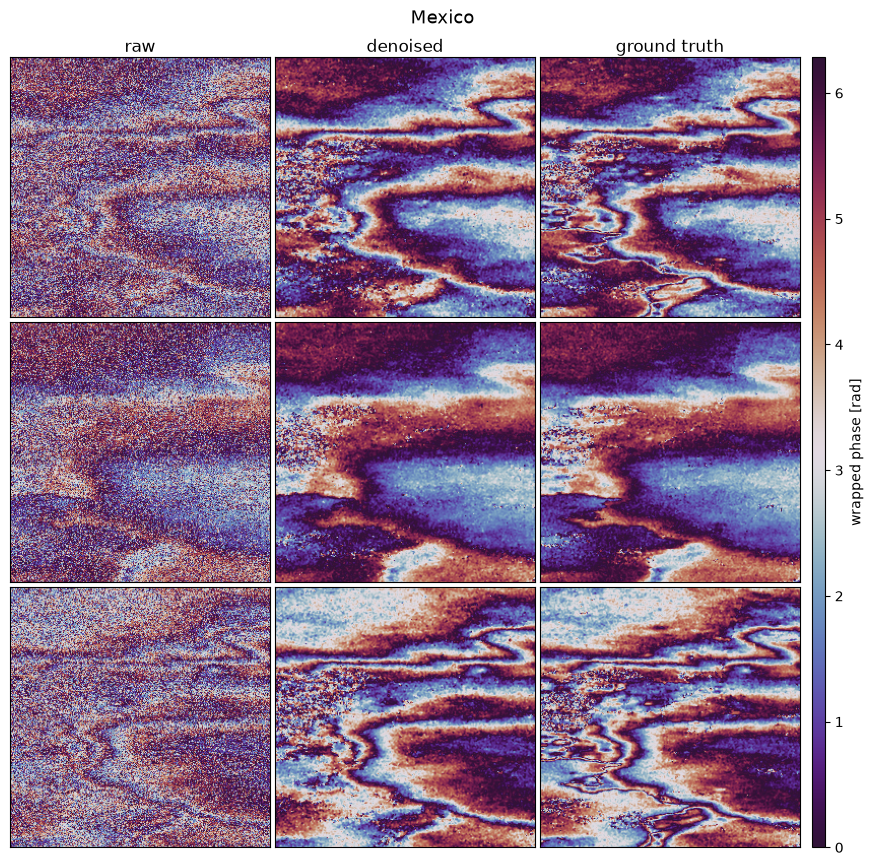

In [5]:

mexico_denoised = mexico_insarflow.denoise(mexico_raw.to(DEVICE), steps=N_STEPS, method="midpoint", use_ema=True)
show(mexico_raw, mexico_denoised, mexico_clean, "Mexico", img_size=IMG_SIZE)

## Simulation — synthetic InSAR dataset

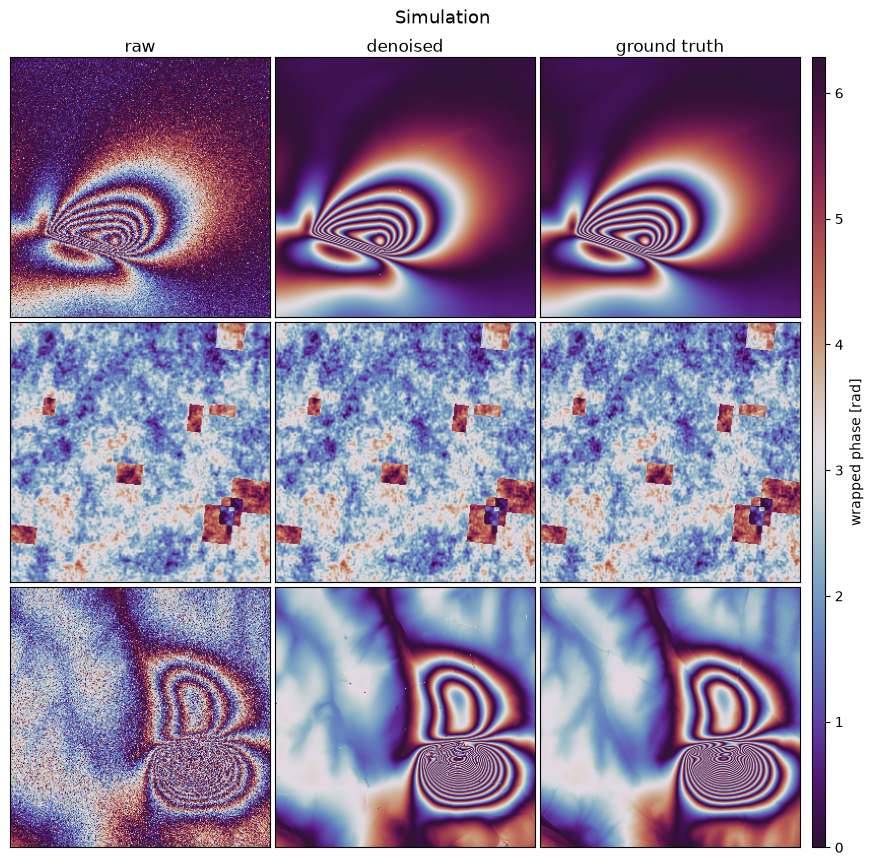

In [6]:
simulation_denoised = simulation_insarflow.denoise(simulation_raw.to(DEVICE), steps=N_STEPS, method="midpoint", use_ema=True)
show(simulation_raw, simulation_denoised, simulation_clean, "Simulation", img_size=IMG_SIZE)

## Cross-domain

Denoise real interferograms from Mexico with a model trained on synthetic data only.

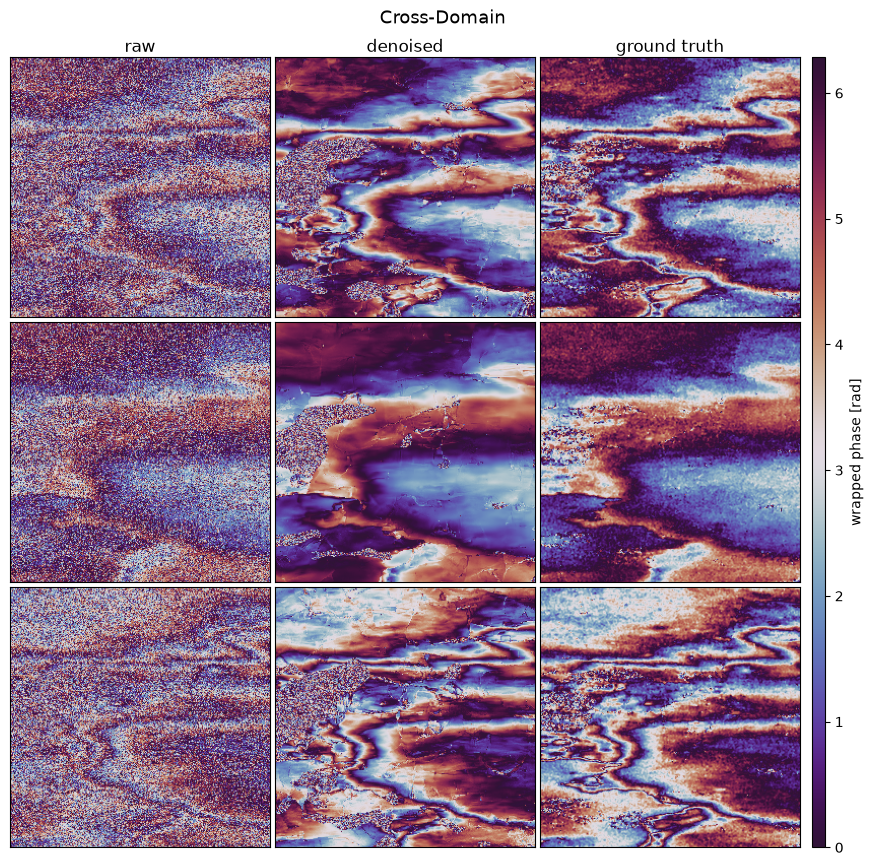

In [7]:
crossdomain_denoised = simulation_insarflow.denoise(mexico_raw.to(DEVICE), steps=N_STEPS, method="midpoint", use_ema=True)
show(mexico_raw, crossdomain_denoised, mexico_clean, "Cross-Domain", img_size=IMG_SIZE)